In [1]:
import numpy as np
import matplotlib.pyplot as plt

import functions as fn
from mastu import HSV

import plotFunctions as pf

In [2]:
%matplotlib widget

In [3]:
resultsFile = '/home/sthoma/Documents/Results/rba/49091/testing_newRz_4.npz'

In [4]:
### load the results
results = np.load(resultsFile)
R = results['R']
data = results['data']
err = results['err']
time = results['time']
# Rgrid = results['Rgrid']
RgridB = results['RgridB']
emissivity = results['emissivity']
emissivityErr = results['emissivityErr']
backprojection = results['backprojection']
# scale = results['scale']
emMax = results['emMax']
emMaxR = results['emMaxR']
emR0 = results['emR0']
emR1 = results['emR1']
emFWHM = results['emFWHM']
emFWHMerr = results['emFWHMerr']
Rind = results['Rind']
Rprofile = results['Rprofile']
# profileTemp = results['profileTemp']
# profileDensity = results['profileDensity']
ioniseRate = results['ioniseRate']
ioniseErr = results['ioniseErr']
neutralDensity = results['neutralDensity']
neutralErr = results['neutralErr']
figN0 = results['figN0']
psiN = results['psiN']
neutralRatio = results['neutralRatio']

In [13]:
I = 0
J = 1

pf.plotResults(
    Rprofile, emissivity[I:J,Rind:], emissivityErr[I:J,Rind:], 
    emMaxR[I:J], emMax[I:J], emR0[I:J], emR1[I:J], emFWHM[I:J], emFWHMerr[I:J], 
    ioniseRate[I:J], ioniseErr[I:J], neutralDensity[I:J], neutralErr[I:J], 
    time[I:J], figN0=figN0[I:J], neutralRatio=neutralRatio[I:J], 
    psiN=psiN[I:J], 
)

IndexError: invalid index to scalar variable.

In [8]:
def findPosition(x, y, mult, kind='exp'):
    """
    kind must be either 'linear' or 'exp'
    """
    ind = y.argmax()
    yMax = y[ind]
    if kind == 'exp':
        cutoff = yMax * np.exp(mult)
    elif kind == 'linear': 
        cutoff = yMax * mult
    x0 = np.interp(cutoff, y[:ind+1], x[:ind+1])
    x1 = np.interp(cutoff, y[ind:][::-1], x[ind:][::-1])
    return x0, x1

def findPositionErr(x, y, yErr, mult, x0=None, x1=None, kind='exp'):
    xA, xB = findPosition(x, y+yErr, mult, kind=kind)
    xa, xb = findPosition(x, y-yErr, mult, kind=kind)
    if (x0 is None) or (x1 is None):
        x0, x1 = findPosition(x, y, mult, kind=kind)
    x0Err = np.max([abs(x0-xA), abs(x0-xa)])
    x1Err = np.max([abs(x1-xB), abs(x1-xB)])
    err = np.sqrt(x0Err**2 + x1Err**2)
    return err

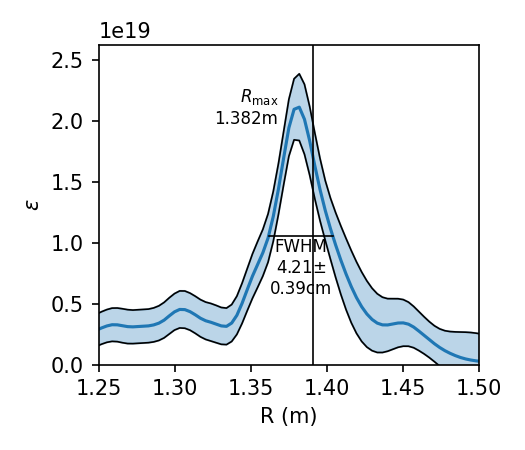

In [9]:
fig, ax = plt.subplots(1,1,figsize=(3.5,3), dpi=150)
ax.plot(RgridB, emissivity[I])
ax.fill_between(RgridB, emissivity[I]+emissivityErr[I], emissivity[I]-emissivityErr[I], color='C0', alpha=0.3)
ax.plot(RgridB, emissivity[I]+emissivityErr[I], '-k', lw=0.8)
ax.plot(RgridB, emissivity[I]-emissivityErr[I], '-k', lw=0.8)

# emMax = emissivity[I].max()
emMaxInd = emissivity[I].argmax()
Rmax = RgridB[emMaxInd]
R0, R1 = findPosition(RgridB, emissivity[I], 0.5, kind='linear')
fwhm = R1 - R0
fwhmErr = findPositionErr(RgridB, emissivity[I], emissivityErr[I], 0.5, x0=R0, x1=R1, kind='linear')

ax.plot([1.3905,1.3905], [0.,3e19], '-', lw=0.8, c='k')
ax.text(Rmax*0.99, emissivity[I,emMaxInd], f'$R_\\mathrm{{max}}$\n{Rmax:.3f}m', 
       ha='right', va='center', fontsize=8)
ax.plot([R0,R1], [emMax/2.,emMax/2.], '-k', lw=0.8)
ax.text(np.mean([R0,R1]), 0.98*emMax/2., f'FWHM\n{fwhm*100:.2f}$\\pm$\n{fwhmErr*100:.2f}cm', 
        ha='center', va='top', fontsize=8)

ax.set_xlim([1.25, 1.50])
ax.set_ylim([0., (emissivity[I]+emissivityErr[I]).max()*1.1])
ax.set_xlabel('R (m)')
ax.set_ylabel('$\\epsilon$')

plt.tight_layout()

In [11]:
pf.plotResults(
    Rprofile, emissivity[I:J,Rind:], emissivityErr[I:J,Rind:], 
    emMaxR[I:J], emMax[I:J], emR0[I:J], emR1[I:J], emFWHM[I:J], emFWHMerr[I:J], 
    ioniseRate[I:J], ioniseErr[I:J], neutralDensity[I:J], neutralErr[I:J], 
    time[I:J], figN0=figN0[I:J], neutralRatio=neutralRatio[I:J], 
    psiN=psiN[I:J], 
)


n0max = neutralDensity[I].max()
n0xind = neutralDensity[I].argmax()

i=0
plt.plot([1.25,1.5], [n0max,n0max], '-', c=f'C{i}', lw=0.8)
Rval = Rprofile[n0xind]
plt.plot([Rval,Rval], [4e14,8e16], '-', c=f'C{i}', lw=0.8)

i=1
plt.plot([1.25,1.5], [n0max*np.exp(-i),n0max*np.exp(-i)], '-', c=f'C{i}', lw=0.8)
R0, R1 = findPosition(Rprofile, neutralDensity[I], -i, kind='exp')
plt.plot([R0,R0], [4e14,8e16], '-', c=f'C{i}', lw=0.8)
plt.plot([R1,R1], [4e14,8e16], '--', c=f'C{i}', lw=0.8)

i=2
plt.plot([1.25,1.5], [n0max*np.exp(-i),n0max*np.exp(-i)], '-', c=f'C{i+1}', lw=0.8)
R0, R1 = findPosition(Rprofile, neutralDensity[I], -i, kind='exp')
plt.plot([R0,R0], [4e14,8e16], '-', c=f'C{i+1}', lw=0.8)
plt.plot([R1,R1], [4e14,8e16], '--', c=f'C{i+1}', lw=0.8)

i=3
plt.plot([1.25,1.5], [n0max*np.exp(-i),n0max*np.exp(-i)], '-', c=f'C{i+1}', lw=0.8)
R0, R1 = findPosition(Rprofile, neutralDensity[I], -i, kind='exp')
plt.plot([R0,R0], [4e14,8e16], '-', c=f'C{i+1}', lw=0.8)
plt.plot([R1,R1], [4e14,8e16], '--', c=f'C{i+1}', lw=0.8)

IndexError: invalid index to scalar variable.

In [12]:
emMaxR

array([1.38179332])